# Pretrained VMamba-T

This self-contained experiment loads an ImageNet-pretrained VMamba-T backbone, freezes it, and trains a new two-class classifier for 20 epochs. It is directly comparable in purpose to the pretrained DINOv2 feature-extractor experiment.

The backbone features are computed once and cached in memory, so the classifier epochs are fast. The shared manifest supplies 176 training images and 45 validation images. There is no independent test set.

In [1]:
import csv
import hashlib
import json
import os
import random
import sys
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms

project_candidates = [
    Path.home() / 'Documents' / 'Paper replication',
    Path.home() / 'Desktop' / 'Paper replication',
]
PROJECT_ROOT = next(
    (path for path in project_candidates if (path / 'data' / 'common_split_manifest.csv').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the Paper replication project in Documents or Desktop.')

MODEL_FOLDER = PROJECT_ROOT / 'model_reproductions' / '04_vmamba_pretrained'
MANIFEST = PROJECT_ROOT / 'data' / 'common_split_manifest.csv'
PRETRAINED_CHECKPOINT = MODEL_FOLDER / 'pretrained' / 'vmamba_tiny_imagenet.pth'
CHECKPOINT_URL = (
    'https://github.com/MzeroMiko/VMamba/releases/download/'
    '%23v2cls/vssm1_tiny_0230s_ckpt_epoch_264.pth'
)
CHECKPOINT_SHA256 = 'd855b57224a652bc692804932f88dc3a39b9028e64be99f745a7fd6792ca672a'
OUTPUT_FOLDER = MODEL_FOLDER / 'results_pretrained'
CLASS_NAMES = ['Low', 'High']
IMAGE_SIZE = 224
EPOCHS = 20
LEARNING_RATE = 1e-3

if str(MODEL_FOLDER) not in sys.path:
    sys.path.insert(0, str(MODEL_FOLDER))
warnings.filterwarnings('ignore', message='Triton not installed.*')
warnings.filterwarnings('ignore', message='Importing from timm.models.layers is deprecated.*')
warnings.filterwarnings('ignore', message='`torch.cuda.amp.custom_.*')
from vmamba_official import vmamba_tiny_s1l8

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

def choose_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

def ensure_pretrained_checkpoint():
    PRETRAINED_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
    if not PRETRAINED_CHECKPOINT.is_file():
        print('Downloading the official ImageNet-pretrained VMamba-T checkpoint ...')
        urlretrieve(CHECKPOINT_URL, PRETRAINED_CHECKPOINT)
    digest = hashlib.sha256(PRETRAINED_CHECKPOINT.read_bytes()).hexdigest()
    if digest != CHECKPOINT_SHA256:
        raise RuntimeError(
            f'Checkpoint SHA-256 mismatch: expected {CHECKPOINT_SHA256}, got {digest}'
        )
    return PRETRAINED_CHECKPOINT

/Users/olzh/Documents/Paper replication/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def read_split():
    with MANIFEST.open(newline='', encoding='utf-8') as file:
        rows = list(csv.DictReader(file))
    train, validation = [], []
    for row in rows:
        folder = 'combined_high_bw' if int(row['label']) else 'combined_low_bw'
        path = MANIFEST.parent / folder / row['file']
        if not path.is_file():
            raise FileNotFoundError(path)
        sample = (path, int(row['label']), row['file'])
        (validation if row['split'] == 'validation' else train).append(sample)
    assert len(train) == 176 and len(validation) == 45
    assert not ({sample[2] for sample in train} & {sample[2] for sample in validation})
    return train, validation

class ImageDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225),
            ),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label, filename = self.samples[index]
        image = Image.open(path).convert('L').convert('RGB')
        return self.transform(image), label, filename

def make_image_loaders(batch_size=8):
    train, validation = read_split()
    train_loader = DataLoader(
        ImageDataset(train), batch_size=batch_size, shuffle=False, num_workers=0,
    )
    validation_loader = DataLoader(
        ImageDataset(validation), batch_size=batch_size, shuffle=False, num_workers=0,
    )
    return train_loader, validation_loader

def extract_features(backbone, loader, device):
    backbone.eval()
    features_out, labels_out, filenames = [], [], []
    with torch.inference_mode():
        for batch_number, (images, labels, names) in enumerate(loader, start=1):
            features_out.append(backbone(images.to(device)).cpu())
            labels_out.append(labels)
            filenames.extend(names)
            print(f'Feature batch {batch_number}/{len(loader)}', end='\r')
    print()
    return torch.cat(features_out), torch.cat(labels_out), filenames

In [3]:
class PretrainedVMamba(nn.Module):
    def __init__(self, checkpoint_path, classes=2):
        super().__init__()
        self.backbone = vmamba_tiny_s1l8(pretrained=False)
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
        state = checkpoint.get('model', checkpoint)
        self.backbone.load_state_dict(state, strict=True)
        self.backbone.classifier.head = nn.Identity()
        self.head = nn.Linear(768, classes)
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

    def forward(self, images):
        return self.head(self.backbone(images))

In [4]:
def feature_epoch(head, loader, loss_function, device, optimizer=None):
    training = optimizer is not None
    head.train(training)
    total_loss, correct = 0.0, 0
    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            scores = head(features)
            loss = loss_function(scores, labels)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += int((scores.argmax(1) == labels).sum())
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate_head(head, features, labels, filenames, loss_function, device):
    head.eval()
    scores_out = []
    with torch.inference_mode():
        for start in range(0, len(labels), 32):
            scores_out.append(head(features[start:start + 32].to(device)).cpu())
    scores = torch.cat(scores_out)
    probabilities = torch.softmax(scores, dim=1)
    predicted = scores.argmax(1)
    loss = loss_function(scores, labels).item()
    actual_list, predicted_list = labels.tolist(), predicted.tolist()
    report = classification_report(
        actual_list, predicted_list, labels=[0, 1], target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    correct = int((predicted == labels).sum())
    metrics = {
        'validation_loss': loss, 'validation_accuracy': correct / len(labels),
        'correct_predictions': correct,
        'incorrect_predictions': len(labels) - correct,
        'prediction_count': len(labels),
        'confusion_matrix': confusion_matrix(
            actual_list, predicted_list, labels=[0, 1]
        ).tolist(),
        'Low': report['Low'], 'High': report['High'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score'],
    }
    predictions = list(zip(
        filenames, actual_list, predicted_list, probabilities.tolist()
    ))
    return metrics, predictions

def save_evaluation(name, head, features, labels, filenames, loss_function, device, output_dir):
    metrics, predictions = evaluate_head(
        head, features, labels, filenames, loss_function, device
    )
    (output_dir / f'{name}_metrics.json').write_text(json.dumps(metrics, indent=2))
    with (output_dir / f'{name}_predictions.csv').open('w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['file', 'true_label', 'predicted_label', 'probability_low', 'probability_high', 'correct'])
        for filename, true, prediction, probs in predictions:
            writer.writerow([filename, true, prediction, probs[0], probs[1], true == prediction])
    return metrics

In [5]:
def train_pretrained_vmamba(model, output_dir):
    set_seed(42)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    device = choose_device()
    model.to(device)
    image_train, image_validation = make_image_loaders(batch_size=8)

    print(f'Extracting fixed pretrained features on {device} ...')
    train_features, train_labels, _ = extract_features(
        model.backbone, image_train, device
    )
    validation_features, validation_labels, validation_filenames = extract_features(
        model.backbone, image_validation, device
    )
    train_loader = DataLoader(
        TensorDataset(train_features, train_labels), batch_size=16, shuffle=True,
        generator=torch.Generator().manual_seed(42),
    )
    validation_loader = DataLoader(
        TensorDataset(validation_features, validation_labels),
        batch_size=16, shuffle=False,
    )
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.head.parameters(), lr=LEARNING_RATE, weight_decay=1e-4
    )

    history = []
    best_loss, best_accuracy, best_accuracy_loss = float('inf'), -1.0, float('inf')
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_accuracy = feature_epoch(
            model.head, train_loader, loss_function, device, optimizer
        )
        validation_loss, validation_accuracy = feature_epoch(
            model.head, validation_loader, loss_function, device
        )
        row = {
            'epoch': epoch, 'training_accuracy': train_accuracy,
            'validation_accuracy': validation_accuracy,
            'training_loss': train_loss, 'validation_loss': validation_loss,
        }
        history.append(row)
        print(json.dumps(row))
        if validation_loss < best_loss:
            best_loss = validation_loss
            torch.save(model.head.state_dict(), output_dir / 'best_validation_loss.pth')
        if validation_accuracy > best_accuracy or (
            validation_accuracy == best_accuracy and validation_loss < best_accuracy_loss
        ):
            best_accuracy, best_accuracy_loss = validation_accuracy, validation_loss
            torch.save(model.head.state_dict(), output_dir / 'best_validation_accuracy.pth')
    torch.save(model.head.state_dict(), output_dir / 'final_epoch.pth')

    accuracy_rows = [
        {key: row[key] for key in ('epoch', 'training_accuracy', 'validation_accuracy')}
        for row in history
    ]
    with (output_dir / 'accuracy_by_epoch.csv').open('w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=list(accuracy_rows[0]))
        writer.writeheader()
        writer.writerows(accuracy_rows)

    epochs = [row['epoch'] for row in history]
    training_accuracy = [row['training_accuracy'] for row in history]
    validation_accuracy = [row['validation_accuracy'] for row in history]
    figure, axis = plt.subplots(figsize=(9, 5.5))
    axis.plot(epochs, training_accuracy, 'o-', linewidth=2, label='Training accuracy')
    axis.plot(epochs, validation_accuracy, 'o-', linewidth=2, label='Validation accuracy')
    for values, label in ((training_accuracy, 'Training'), (validation_accuracy, 'Validation')):
        best_index = int(np.argmax(values))
        horizontal_offset = 70 if epochs[best_index] <= 3 else 0
        axis.scatter(epochs[best_index], values[best_index], s=80, zorder=5)
        axis.annotate(
            f'{label} max: {values[best_index]:.1%}',
            (epochs[best_index], values[best_index]),
            xytext=(horizontal_offset, 12), textcoords='offset points', ha='center',
        )
    axis.set(
        xlabel='Epoch', ylabel='Accuracy', title='Pretrained VMamba-T accuracy',
        xlim=(1, EPOCHS), ylim=(0, 1.08),
    )
    axis.grid(alpha=0.25)
    axis.legend()
    figure.tight_layout()
    figure.savefig(output_dir / 'accuracy_graph.png', dpi=220, bbox_inches='tight')
    if 'ipykernel' in sys.modules:
        plt.show()
    plt.close(figure)

    summary = {}
    for name, checkpoint in (
        ('final', 'final_epoch.pth'),
        ('best_loss', 'best_validation_loss.pth'),
        ('best_accuracy', 'best_validation_accuracy.pth'),
    ):
        model.head.load_state_dict(
            torch.load(output_dir / checkpoint, map_location=device, weights_only=True)
        )
        summary[name] = save_evaluation(
            name, model.head, validation_features, validation_labels,
            validation_filenames, loss_function, device, output_dir,
        )

    result_rows = [
        {
            'checkpoint': name,
            'validation_accuracy': metrics['validation_accuracy'],
            'validation_loss': metrics['validation_loss'],
            'correct_predictions': metrics['correct_predictions'],
            'incorrect_predictions': metrics['incorrect_predictions'],
            'macro_f1': metrics['macro_f1'],
            'weighted_f1': metrics['weighted_f1'],
        }
        for name, metrics in summary.items()
    ]
    with (output_dir / 'validation_results.csv').open('w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=list(result_rows[0]))
        writer.writeheader()
        writer.writerows(result_rows)

    configuration = {
        'model': 'VMamba-T',
        'method': 'ImageNet-pretrained frozen backbone and classifier training',
        'pretrained_checkpoint': str(PRETRAINED_CHECKPOINT),
        'checkpoint_scope': 'classification head only',
        'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'seed': 42,
        'training_images': 176, 'validation_images': 45, 'test_images': 0,
        'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'total_parameters': sum(p.numel() for p in model.parameters()), 'device': str(device),
    }
    (output_dir / 'run_configuration.json').write_text(json.dumps(configuration, indent=2))
    (output_dir / 'result_summary.json').write_text(json.dumps(summary, indent=2))
    print('\nValidation results:')
    for row in result_rows:
        print(f"{row['checkpoint']:>13}: {row['validation_accuracy']:.2%} "
              f"({row['correct_predictions']}/45 correct)")
    return summary

Loaded ImageNet-pretrained VMamba-T: 29,481,602 total parameters; 1,538 trainable classifier parameters
Extracting fixed pretrained features on mps ...


Feature batch 22/22


Feature batch 6/6
{"epoch": 1, "training_accuracy": 0.6534090909090909, "validation_accuracy": 0.8444444444444444, "training_loss": 0.6002747551961378, "validation_loss": 0.43050529691908096}
{"epoch": 2, "training_accuracy": 0.8579545454545454, "validation_accuracy": 0.9555555555555556, "training_loss": 0.3998927121812647, "validation_loss": 0.31120473345120747}
{"epoch": 3, "training_accuracy": 0.9204545454545454, "validation_accuracy": 0.9555555555555556, "training_loss": 0.2992846369743347, "validation_loss": 0.23026634587181938}


{"epoch": 4, "training_accuracy": 0.9204545454545454, "validation_accuracy": 0.9555555555555556, "training_loss": 0.2533099935813384, "validation_loss": 0.19980432523621453}
{"epoch": 5, "training_accuracy": 0.9545454545454546, "validation_accuracy": 0.9777777777777777, "training_loss": 0.22388322515921158, "validation_loss": 0.1823226061132219}
{"epoch": 6, "training_accuracy": 0.9602272727272727, "validation_accuracy": 0.9777777777777777, "training_loss": 0.20789901167154312, "validation_loss": 0.1688203208976322}
{"epoch": 7, "training_accuracy": 0.9659090909090909, "validation_accuracy": 0.9777777777777777, "training_loss": 0.19735333729874005, "validation_loss": 0.15778583553102282}
{"epoch": 8, "training_accuracy": 0.9602272727272727, "validation_accuracy": 0.9777777777777777, "training_loss": 0.19236959517002106, "validation_loss": 0.15113294786877102}
{"epoch": 9, "training_accuracy": 0.9715909090909091, "validation_accuracy": 0.9777777777777777, "training_loss": 0.183130997825

{"epoch": 13, "training_accuracy": 0.9602272727272727, "validation_accuracy": 0.9777777777777777, "training_loss": 0.16648243096741763, "validation_loss": 0.1256302879916297}
{"epoch": 14, "training_accuracy": 0.9715909090909091, "validation_accuracy": 0.9777777777777777, "training_loss": 0.16753520545634357, "validation_loss": 0.12613186637560528}
{"epoch": 15, "training_accuracy": 0.9659090909090909, "validation_accuracy": 0.9777777777777777, "training_loss": 0.15536477213556116, "validation_loss": 0.11990218626128303}
{"epoch": 16, "training_accuracy": 0.9715909090909091, "validation_accuracy": 0.9777777777777777, "training_loss": 0.15582428127527237, "validation_loss": 0.11994623872968886}
{"epoch": 17, "training_accuracy": 0.9772727272727273, "validation_accuracy": 0.9777777777777777, "training_loss": 0.14896614375439557, "validation_loss": 0.1149997055530548}
{"epoch": 18, "training_accuracy": 0.9772727272727273, "validation_accuracy": 0.9777777777777777, "training_loss": 0.14684

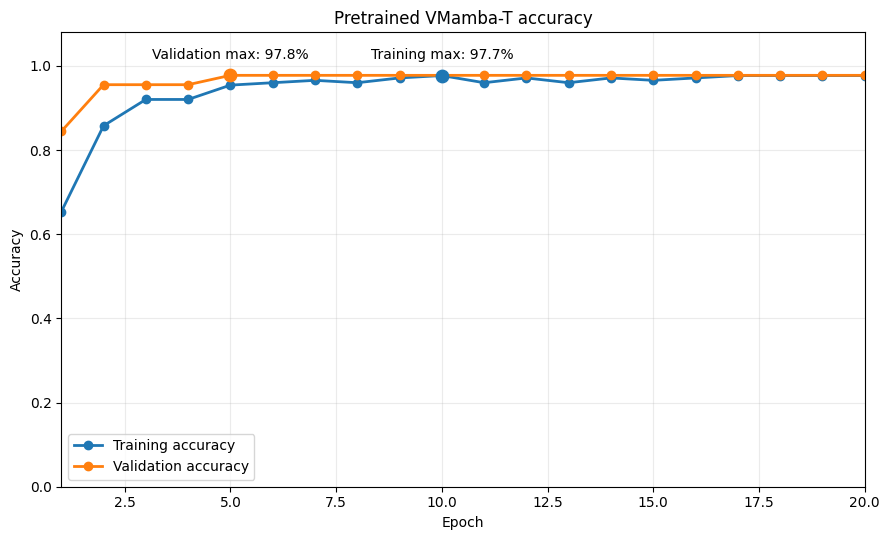


Validation results:
        final: 97.78% (44/45 correct)
    best_loss: 97.78% (44/45 correct)
best_accuracy: 97.78% (44/45 correct)


In [6]:
set_seed(42)
checkpoint_path = ensure_pretrained_checkpoint()
model = PretrainedVMamba(checkpoint_path, classes=2)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
assert trainable_parameters == 1_538
print(
    f'Loaded ImageNet-pretrained VMamba-T: {total_parameters:,} total parameters; '
    f'{trainable_parameters:,} trainable classifier parameters'
)
results = train_pretrained_vmamba(model, OUTPUT_FOLDER)

The `results_pretrained` folder contains the epoch accuracy CSV, checkpoint summary CSV, per-image validation predictions, accuracy graph, three lightweight classifier checkpoints, and run configuration. The ImageNet-pretrained backbone remains unchanged in `pretrained/vmamba_tiny_imagenet.pth`.

There is no independent test split, so all held-out scores are correctly reported as **validation accuracy**.